<div style="display: flex; align-items: center; justify-content: center; flex-wrap: wrap;">
    <div style="flex: 1; max-width: 400px; display: flex; justify-content: center;">
        <img src="https://magic.novaims.unl.pt/media/1tdf2arr/ims25_horizontal__positivo_rgb.svg" style="max-width: 70%; height: auto; margin-top: 50px; margin-bottom: 50px; margin-left: 6rem;">
    </div>
    <div style="flex: 2; text-align: center; margin-top: 20px; margin-left: 6rem;">
        <div style="font-size: 28px; font-weight: bold; line-height: 1.2;">
            <span style="color: #FFCD41;">Thesis Project |</span> <span style="color: #F58228;">LISBOA Evaluation Results Analysis</span>
        </div>
        <div style="font-size: 17px; font-weight: bold; margin-top: 10px;">2025 - 2026</div>
        <div style="font-size: 17px; font-weight: bold;">Master in Data Science and Advanced Analytics</div>
        <div style="margin-top: 20px;"><div>André Filipe Gomes Silvestre, 20240502</div></div>
    </div>
</div>

<style>
@import url('https://fonts.cdnfonts.com/css/avenir-next-lt-pro?styles=29974');
</style>

<div style="background: linear-gradient(to right, #F58228, #FFCD41); padding: 15px; color: white; border-radius: 300px; text-align: center;">
    <center><h1 style="margin-left: 100px; margin-top: 10px; margin-bottom: 4px; color: white; font-size: 32px; font-family: 'Avenir Next LT Pro', sans-serif;"><b>Benchmark and Ablation Analysis</b></h1></center>
</div>

<br><br>

## **📝 Notebook Overview**

This notebook automatically loads the latest **benchmark** and **ablation** JSON artefacts under `eval/results/`, flattens the nested structures into analysis-friendly tables, and produces exportable plots for the thesis methodology chapter.

### **🎯 Goals**

1. Inspect the most recent benchmark and ablation artefacts.
2. Compare response models, evaluator model, score distributions, tool-usage quality, heuristics, and latency.
3. Keep a reproducible visual workflow with figures exported automatically to `eval/results/figures`.
4. Provide markdown-ready tables that explain the JSON artefacts used in the evaluation pipeline.

In [ ]:
# ==========================================================================
# Required libraries
# ==========================================================================
# pip install pandas numpy matplotlib seaborn

import json
import re
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib import font_manager
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from matplotlib.patches import Patch

%matplotlib inline


def resolve_project_root() -> Path:
    """Resolve the repository root even if the notebook is opened from a subfolder."""
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'config.py').exists() and (candidate / 'eval' / 'results').exists():
            return candidate
    return Path.cwd()


def pick_plot_font() -> str:
    """Pick the closest available font to the notebook reference style."""
    preferred_fonts = ['Avenir Next LT Pro', 'Avenir Next', 'Arial', 'DejaVu Sans']
    available_fonts = {font.name for font in font_manager.fontManager.ttflist}
    for font_name in preferred_fonts:
        if font_name in available_fonts:
            return font_name
    return 'DejaVu Sans'


def format_model_label(model_name: str | None) -> str:
    """Format model labels for notebook display without provider prefixes."""
    if model_name is None:
        return 'N/A'

    label = str(model_name).strip()
    special_labels = {
        'Multi-Agent (gpt-5-mini)': 'LISBOA Multi-Agent',
        'multi_agent': 'LISBOA Multi-Agent',
        'zero_shot': 'Zero-shot',
        'lisboa': 'LISBOA',
    }
    if label in special_labels:
        return special_labels[label]

    if '::' in label:
        label = label.split('::', 1)[1]

    if label.lower().startswith('multi-agent'):
        return 'LISBOA Multi-Agent'

    gpt_match = re.fullmatch(r'gpt-(\d+(?:\.\d+)?)(?:-(.+))?', label.lower())
    if gpt_match:
        version, variant = gpt_match.groups()
        if variant:
            formatted_variant = ' '.join(
                part.upper() if len(part) <= 2 else part.capitalize()
                for part in variant.split('-')
            )
            return f'GPT-{version} {formatted_variant}'
        return f'GPT-{version}'

    return label.replace('_', ' ').replace('-', ' ').title()


DOMAIN_LABELS = {
    'weather': 'Weather',
    'transport': 'Transport',
    'researcher': 'Researcher',
    'multi_agent': 'Multi-agent',
    'greeting': 'Greeting',
    'out_of_scope': 'Out of scope',
}


def format_domain_label(domain_name: str | None) -> str:
    """Format evaluation domains for notebook display."""
    if domain_name is None:
        return 'Unknown'
    return DOMAIN_LABELS.get(str(domain_name), str(domain_name).replace('_', ' ').title())


def format_arm_label(arm_name: str | None) -> str:
    """Format ablation arm names for notebook display."""
    mapping = {'zero_shot': 'Zero-shot', 'lisboa': 'LISBOA'}
    if arm_name is None:
        return 'Unknown'
    return mapping.get(str(arm_name), str(arm_name).replace('_', ' ').title())


PROJECT_ROOT = resolve_project_root()
EVAL_RESULTS_DIR = PROJECT_ROOT / 'eval' / 'results'
FIGURES_DIR = EVAL_RESULTS_DIR / 'figures'
EXPORT_DPI = 300
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PLOT_FONT = pick_plot_font()

PRIMARY_RED = '#ff4011'
SECONDARY_ORANGE = '#f58228'
ACCENT_YELLOW = '#f6da00'
NEUTRAL_GREY = '#7a7a7a'
LIGHT_GREY = '#d9d9d9'
DARK_GREY = '#2f2f2f'

PROJECT_PALETTE = [PRIMARY_RED, SECONDARY_ORANGE, ACCENT_YELLOW, NEUTRAL_GREY]
DOMAIN_PALETTE = {
    'Weather': PRIMARY_RED,
    'Transport': SECONDARY_ORANGE,
    'Researcher': ACCENT_YELLOW,
}
ARM_PALETTE = {
    'Zero-shot': NEUTRAL_GREY,
    'LISBOA': PRIMARY_RED,
}
DOMAIN_ORDER = ['Weather', 'Transport', 'Researcher']
ABLATION_DOMAIN_ORDER = ['Greeting', 'Weather', 'Transport', 'Researcher', 'Multi-agent', 'Out of scope']

sns.set_theme(context='notebook', style='whitegrid', font=PLOT_FONT, font_scale=1.0)
sns.set_palette(PROJECT_PALETTE)
plt.rcParams['figure.figsize'] = (15, 7)
plt.rcParams['figure.dpi'] = EXPORT_DPI
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 10.5
plt.rcParams['ytick.labelsize'] = 10.5
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['legend.title_fontsize'] = 10
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [PLOT_FONT, 'Arial', 'DejaVu Sans']
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['axes.edgecolor'] = DARK_GREY
plt.rcParams['text.color'] = DARK_GREY
plt.rcParams['axes.labelcolor'] = DARK_GREY
plt.rcParams['xtick.color'] = DARK_GREY
plt.rcParams['ytick.color'] = DARK_GREY

print(f'Project root: {PROJECT_ROOT}')
print(f'Figures directory: {FIGURES_DIR}')
print(f'Plot font: {PLOT_FONT}')

Project root: c:\Users\andre\OneDrive - NOVAIMS\[MDSAA-DS]_Thesis\Thesis2025-26_AFGS
Figures directory: c:\Users\andre\OneDrive - NOVAIMS\[MDSAA-DS]_Thesis\Thesis2025-26_AFGS\eval\results\figures
Plot font: Avenir Next LT Pro


In [8]:
# ==========================================================================
# Helpers
# ==========================================================================
def find_latest_artifact(subdir: str, prefix: str, required: bool = True) -> Path | None:
    artifact_dir = EVAL_RESULTS_DIR / subdir
    matches = sorted(artifact_dir.glob(f'{prefix}_*.json'))
    if not matches:
        if required:
            raise FileNotFoundError(f'No artefacts found in {artifact_dir} matching {prefix}_*.json')
        return None
    return matches[-1]


def load_json(path: Path | None) -> dict[str, Any] | None:
    if path is None:
        return None
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)


def load_required_json(path: Path) -> dict[str, Any]:
    payload = load_json(path)
    if payload is None:
        raise ValueError(f'Expected JSON payload at {path}, but found None.')
    return payload


def save_figure(name: str, fig: Figure | None = None) -> Path:
    """Export only SVG and remove obsolete PNG/PDF versions."""
    fig = fig or plt.gcf()
    fig.patch.set_facecolor('white')
    for ax in fig.axes:
        ax.set_facecolor('white')
    for ext in ('png', 'pdf'):
        legacy_path = FIGURES_DIR / f'{name}.{ext}'
        if legacy_path.exists():
            legacy_path.unlink()
    svg_path = FIGURES_DIR / f'{name}.svg'
    fig.savefig(svg_path, format='svg', bbox_inches='tight', facecolor='white')
    print(f'Exported: {svg_path.name}')
    return svg_path


def style_axis(
    ax: Axes,
    title: str,
    xlabel: str,
    ylabel: str,
    *,
    rotate_xticks: int = 0,
    y_limits: tuple[float, float] | None = None,
    show_y_grid: bool = True,
) -> None:
    """Apply a thesis-ready visual style to an axis."""
    ax.set_facecolor('white')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel(f'\n{xlabel}', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'{ylabel}\n', fontsize=12, fontweight='bold')
    if y_limits is not None:
        ax.set_ylim(*y_limits)
    ax.tick_params(axis='x', rotation=rotate_xticks)
    if show_y_grid:
        ax.grid(True, axis='y', linestyle='--', alpha=0.7, color='lightgrey')
    else:
        ax.grid(False, axis='y')
    sns.despine(ax=ax, left=True, bottom=True)


def style_legend(
    ax: Axes,
    title: str,
    bbox_to_anchor: tuple[float, float] = (1.02, 1.0),
) -> None:
    """Move and style a legend consistently across plots."""
    if ax.legend_ is None:
        return
    sns.move_legend(ax, 'upper left', bbox_to_anchor=bbox_to_anchor, title=title, frameon=True)
    if ax.legend_ is None:
        return
    ax.legend_.get_title().set_fontweight('bold')
    ax.legend_.get_frame().set_edgecolor('#d0d0d0')
    ax.legend_.get_frame().set_linewidth(0.8)
    ax.legend_.get_frame().set_alpha(0.98)


def build_metric_boxplot(
    ax: Axes,
    data: pd.DataFrame,
    *,
    x: str,
    y: str,
    hue: str,
    palette: dict[str, str],
    order: list[str],
    hue_order: list[str],
    title: str,
    xlabel: str,
    ylabel: str,
    rotate_xticks: int = 0,
    y_limits: tuple[float, float] | None = None,
    legend_title: str = '',
    show_legend: bool = True,
) -> None:
    """Create a styled boxplot aligned with the notebook reference aesthetics."""
    sns.boxplot(
        x=x,
        y=y,
        hue=hue,
        data=data,
        palette=palette,
        width=0.45,
        fliersize=5,
        linewidth=1.5,
        order=order,
        hue_order=hue_order,
        saturation=1,
        boxprops=dict(edgecolor='black'),
        whiskerprops=dict(color='black', linewidth=1.2),
        capprops=dict(color='black', linewidth=1.2),
        medianprops=dict(color='black', linewidth=1.6),
        ax=ax,
    )
    style_axis(
        ax,
        title,
        xlabel,
        ylabel,
        rotate_xticks=rotate_xticks,
        y_limits=y_limits,
        show_y_grid=True,
    )
    if show_legend and ax.legend_ is not None:
        style_legend(ax, legend_title)
    elif ax.legend_ is not None:
        ax.legend_.remove()


def format_response_models_for_inventory(value: Any) -> str:
    """Format response model inventories for display without provider prefixes."""
    if isinstance(value, dict):
        return ' | '.join(
            f"{format_arm_label(key)}: {format_model_label(model)}"
            for key, model in value.items()
        )
    if isinstance(value, (list, tuple, set)):
        return ', '.join(format_model_label(model) for model in value)
    if value is None:
        return 'N/A'
    return format_model_label(str(value))


def flatten_benchmark_results(payload: dict[str, Any]) -> pd.DataFrame:
    rows = []
    for record in payload.get('benchmark_results', []):
        scores = record.get('scores') or {}
        heuristics = record.get('heuristics') or {}
        tool_metrics = record.get('tool_metrics') or {}
        rows.append({
            'id': record.get('id'),
            'domain': record.get('domain'),
            'query': record.get('query'),
            'response_model': record.get('response_model'),
            'evaluation_model': record.get('evaluation_model'),
            'latency_s': record.get('latency_s'),
            'composite_score': scores.get('composite_score'),
            'factual_accuracy': scores.get('factual_accuracy'),
            'tool_usage': scores.get('tool_usage'),
            'completeness': scores.get('completeness'),
            'relevance': scores.get('relevance'),
            'response_quality': scores.get('response_quality'),
            'tool_precision': tool_metrics.get('tool_precision'),
            'tool_recall': tool_metrics.get('tool_recall'),
            'tool_f1': tool_metrics.get('tool_f1'),
            'heuristics_pass': heuristics.get('overall_pass'),
            'sla_met': record.get('sla_met'),
            'error_type': record.get('error_type'),
        })
    return pd.DataFrame(rows)


def flatten_ablation_results(payload: dict[str, Any]) -> pd.DataFrame:
    rows = []
    for record in payload.get('ablation_results', []):
        for arm in ('zero_shot', 'lisboa'):
            metrics = record.get('metrics', {}).get(arm, {})
            scores = metrics.get('scores') or {}
            heuristics = metrics.get('heuristics') or {}
            tool_metrics = metrics.get('tool_metrics') or {}
            rows.append({
                'id': record.get('id'),
                'domain': record.get('domain'),
                'query': record.get('query'),
                'arm': arm,
                'response_model': metrics.get('response_model'),
                'evaluation_model': metrics.get('evaluation_model'),
                'latency_s': metrics.get('latency'),
                'composite_score': scores.get('composite_score'),
                'factual_accuracy': scores.get('factual_accuracy'),
                'tool_usage': scores.get('tool_usage'),
                'completeness': scores.get('completeness'),
                'relevance': scores.get('relevance'),
                'response_quality': scores.get('response_quality'),
                'tool_precision': tool_metrics.get('tool_precision'),
                'tool_recall': tool_metrics.get('tool_recall'),
                'tool_f1': tool_metrics.get('tool_f1'),
                'heuristics_pass': heuristics.get('overall_pass'),
                'error_type': metrics.get('error_type'),
            })
    return pd.DataFrame(rows)


def build_artifact_inventory(
    benchmark_path: Path,
    benchmark_payload: dict[str, Any],
    ablation_path: Path,
    ablation_payload: dict[str, Any],
    coverage_path: Path | None = None,
    coverage_payload: dict[str, Any] | None = None,
    calibration_path: Path | None = None,
    calibration_payload: dict[str, Any] | None = None,
) -> pd.DataFrame:
    rows = [
        {
            'artefact': 'benchmark',
            'path': str(benchmark_path.relative_to(PROJECT_ROOT)),
            'record_count': len(benchmark_payload.get('benchmark_results', [])),
            'response_models': format_response_models_for_inventory(
                benchmark_payload.get('benchmark_metadata', {}).get('response_models', [])
            ),
            'evaluation_model': format_model_label(
                benchmark_payload.get('benchmark_metadata', {}).get('evaluation_model')
            ),
            'top_level_keys': ', '.join(benchmark_payload.keys()),
        },
        {
            'artefact': 'ablation',
            'path': str(ablation_path.relative_to(PROJECT_ROOT)),
            'record_count': len(ablation_payload.get('ablation_results', [])),
            'response_models': format_response_models_for_inventory(
                ablation_payload.get('ablation_metadata', {}).get('response_models', {})
            ),
            'evaluation_model': format_model_label(
                ablation_payload.get('ablation_metadata', {}).get('evaluation_model')
            ),
            'top_level_keys': ', '.join(ablation_payload.keys()),
        },
    ]
    if coverage_path and coverage_payload:
        rows.append({
            'artefact': 'coverage',
            'path': str(coverage_path.relative_to(PROJECT_ROOT)),
            'record_count': len(coverage_payload.get('coverage_results', [])),
            'response_models': format_response_models_for_inventory(
                coverage_payload.get('coverage_metadata', {}).get('response_models', {})
            ),
            'evaluation_model': format_model_label(
                coverage_payload.get('coverage_metadata', {}).get('evaluation_model')
            ),
            'top_level_keys': ', '.join(coverage_payload.keys()),
        })
    if calibration_path and calibration_payload:
        rows.append({
            'artefact': 'calibration',
            'path': str(calibration_path.relative_to(PROJECT_ROOT)),
            'record_count': calibration_payload.get('summary', {}).get('matched_count'),
            'response_models': format_response_models_for_inventory(
                calibration_payload.get('calibration_metadata', {}).get('benchmark_response_models')
            ),
            'evaluation_model': format_model_label(
                calibration_payload.get('calibration_metadata', {}).get('benchmark_evaluation_model')
            ),
            'top_level_keys': ', '.join(calibration_payload.keys()),
        })
    return pd.DataFrame(rows)

In [3]:
# ==========================================================================
# Cost and token flattening helpers
# ==========================================================================
def _extract_token_triplet(payload: dict[str, Any] | None) -> tuple[int, int, int]:
    payload = payload or {}
    tokens = payload.get('tokens', {}) or {}
    return (
        int(tokens.get('input_tokens', 0) or 0),
        int(tokens.get('output_tokens', 0) or 0),
        int(tokens.get('total_tokens', 0) or 0),
    )


def _extract_cost_triplet(payload: dict[str, Any] | None) -> tuple[float, float, float]:
    payload = payload or {}
    return (
        float(payload.get('input_cost_usd', 0.0) or 0.0),
        float(payload.get('output_cost_usd', 0.0) or 0.0),
        float(payload.get('total_cost_usd', 0.0) or 0.0),
    )


def flatten_benchmark_results(payload: dict[str, Any]) -> pd.DataFrame:
    rows = []
    for record in payload.get('benchmark_results', []):
        scores = record.get('scores') or {}
        heuristics = record.get('heuristics') or {}
        tool_metrics = record.get('tool_metrics') or {}
        response_usage = record.get('response_usage') or {}
        evaluation_usage = record.get('evaluation_usage') or {}
        combined_usage = record.get('combined_usage') or {}
        response_cost = record.get('response_cost_usd') or {}
        evaluation_cost = record.get('evaluation_cost_usd') or {}
        combined_cost = record.get('combined_cost_usd') or {}

        response_input_tokens, response_output_tokens, response_total_tokens = _extract_token_triplet(response_usage)
        evaluation_input_tokens, evaluation_output_tokens, evaluation_total_tokens = _extract_token_triplet(evaluation_usage)
        combined_input_tokens, combined_output_tokens, combined_total_tokens = _extract_token_triplet(combined_usage)
        response_input_cost, response_output_cost, response_total_cost = _extract_cost_triplet(response_cost)
        evaluation_input_cost, evaluation_output_cost, evaluation_total_cost = _extract_cost_triplet(evaluation_cost)
        combined_input_cost, combined_output_cost, combined_total_cost = _extract_cost_triplet(combined_cost)

        rows.append({
            'id': record.get('id'),
            'domain': record.get('domain'),
            'query': record.get('query'),
            'response_model': record.get('response_model'),
            'evaluation_model': record.get('evaluation_model'),
            'latency_s': record.get('latency_s'),
            'composite_score': scores.get('composite_score'),
            'factual_accuracy': scores.get('factual_accuracy'),
            'tool_usage': scores.get('tool_usage'),
            'completeness': scores.get('completeness'),
            'relevance': scores.get('relevance'),
            'response_quality': scores.get('response_quality'),
            'tool_precision': tool_metrics.get('tool_precision'),
            'tool_recall': tool_metrics.get('tool_recall'),
            'tool_f1': tool_metrics.get('tool_f1'),
            'heuristics_pass': heuristics.get('overall_pass'),
            'sla_met': record.get('sla_met'),
            'error_type': record.get('error_type'),
            'response_call_count': response_usage.get('call_count', 0),
            'evaluation_call_count': evaluation_usage.get('call_count', 0),
            'combined_call_count': combined_usage.get('call_count', 0),
            'response_input_tokens': response_input_tokens,
            'response_output_tokens': response_output_tokens,
            'response_total_tokens': response_total_tokens,
            'evaluation_input_tokens': evaluation_input_tokens,
            'evaluation_output_tokens': evaluation_output_tokens,
            'evaluation_total_tokens': evaluation_total_tokens,
            'combined_input_tokens': combined_input_tokens,
            'combined_output_tokens': combined_output_tokens,
            'combined_total_tokens': combined_total_tokens,
            'response_input_cost_usd': response_input_cost,
            'response_output_cost_usd': response_output_cost,
            'response_total_cost_usd': response_total_cost,
            'evaluation_input_cost_usd': evaluation_input_cost,
            'evaluation_output_cost_usd': evaluation_output_cost,
            'evaluation_total_cost_usd': evaluation_total_cost,
            'combined_input_cost_usd': combined_input_cost,
            'combined_output_cost_usd': combined_output_cost,
            'combined_total_cost_usd': combined_total_cost,
        })
    return pd.DataFrame(rows)


def flatten_ablation_results(payload: dict[str, Any]) -> pd.DataFrame:
    rows = []
    for record in payload.get('ablation_results', []):
        for arm in ('zero_shot', 'lisboa'):
            metrics = record.get('metrics', {}).get(arm, {})
            scores = metrics.get('scores') or {}
            heuristics = metrics.get('heuristics') or {}
            tool_metrics = metrics.get('tool_metrics') or {}
            response_usage = metrics.get('response_usage') or {}
            evaluation_usage = metrics.get('evaluation_usage') or {}
            combined_usage = metrics.get('combined_usage') or {}
            response_cost = metrics.get('response_cost_usd') or {}
            evaluation_cost = metrics.get('evaluation_cost_usd') or {}
            combined_cost = metrics.get('combined_cost_usd') or {}

            response_input_tokens, response_output_tokens, response_total_tokens = _extract_token_triplet(response_usage)
            evaluation_input_tokens, evaluation_output_tokens, evaluation_total_tokens = _extract_token_triplet(evaluation_usage)
            combined_input_tokens, combined_output_tokens, combined_total_tokens = _extract_token_triplet(combined_usage)
            response_input_cost, response_output_cost, response_total_cost = _extract_cost_triplet(response_cost)
            evaluation_input_cost, evaluation_output_cost, evaluation_total_cost = _extract_cost_triplet(evaluation_cost)
            combined_input_cost, combined_output_cost, combined_total_cost = _extract_cost_triplet(combined_cost)

            rows.append({
                'id': record.get('id'),
                'domain': record.get('domain'),
                'query': record.get('query'),
                'arm': arm,
                'response_model': metrics.get('response_model'),
                'evaluation_model': metrics.get('evaluation_model'),
                'latency_s': metrics.get('latency'),
                'composite_score': scores.get('composite_score'),
                'factual_accuracy': scores.get('factual_accuracy'),
                'tool_usage': scores.get('tool_usage'),
                'completeness': scores.get('completeness'),
                'relevance': scores.get('relevance'),
                'response_quality': scores.get('response_quality'),
                'tool_precision': tool_metrics.get('tool_precision'),
                'tool_recall': tool_metrics.get('tool_recall'),
                'tool_f1': tool_metrics.get('tool_f1'),
                'heuristics_pass': heuristics.get('overall_pass'),
                'error_type': metrics.get('error_type'),
                'response_call_count': response_usage.get('call_count', 0),
                'evaluation_call_count': evaluation_usage.get('call_count', 0),
                'combined_call_count': combined_usage.get('call_count', 0),
                'response_input_tokens': response_input_tokens,
                'response_output_tokens': response_output_tokens,
                'response_total_tokens': response_total_tokens,
                'evaluation_input_tokens': evaluation_input_tokens,
                'evaluation_output_tokens': evaluation_output_tokens,
                'evaluation_total_tokens': evaluation_total_tokens,
                'combined_input_tokens': combined_input_tokens,
                'combined_output_tokens': combined_output_tokens,
                'combined_total_tokens': combined_total_tokens,
                'response_input_cost_usd': response_input_cost,
                'response_output_cost_usd': response_output_cost,
                'response_total_cost_usd': response_total_cost,
                'evaluation_input_cost_usd': evaluation_input_cost,
                'evaluation_output_cost_usd': evaluation_output_cost,
                'evaluation_total_cost_usd': evaluation_total_cost,
                'combined_input_cost_usd': combined_input_cost,
                'combined_output_cost_usd': combined_output_cost,
                'combined_total_cost_usd': combined_total_cost,
            })
    return pd.DataFrame(rows)

In [10]:
# ==========================================================================
# Load latest artefacts
# ==========================================================================
benchmark_path = find_latest_artifact('benchmark', 'benchmark_results')
ablation_path = find_latest_artifact('ablation', 'ablation_results')
coverage_path = find_latest_artifact('coverage', 'coverage_results', required=False)
calibration_path = find_latest_artifact('calibration', 'calibration_summary', required=False)

assert benchmark_path is not None
assert ablation_path is not None

benchmark_payload = load_required_json(benchmark_path)
ablation_payload = load_required_json(ablation_path)
coverage_payload = load_json(coverage_path)
calibration_payload = load_json(calibration_path)

artifact_inventory = build_artifact_inventory(
    benchmark_path, benchmark_payload, ablation_path, ablation_payload, coverage_path, coverage_payload, calibration_path, calibration_payload
)

display(Markdown('### **Active JSON artefacts loaded in this session**'))
display(artifact_inventory)

### **Active JSON artefacts loaded in this session**

,artefact,path,record_count,response_models,evaluation_model,top_level_keys
0,benchmark,eval\results\benchmark\benchmark_results_20260...,10,"GPT-5 Mini, GPT-5 Nano",GPT-5 Mini,"benchmark_metadata, summary, benchmark_results"
1,ablation,eval\results\ablation\ablation_results_2026030...,5,Zero-shot: GPT-5 Mini | LISBOA: LISBOA Multi-A...,GPT-5 Mini,"ablation_metadata, summary, ablation_results"


## **📁 JSON artefacts used in this notebook**

| JSON artefact | Typical path pattern | Main top-level keys | Main purpose | Notes |
|---|---|---|---|---|
| Benchmark results | `eval/results/benchmark/benchmark_results_<timestamp>.json` | `benchmark_metadata`, `summary`, `benchmark_results` | Compare worker-agent response models under real-service conditions | Includes explicit response-model configs and evaluator-model config |
| Ablation results | `eval/results/ablation/ablation_results_<timestamp>.json` | `ablation_metadata`, `summary`, `ablation_results` | Compare zero-shot baseline vs full LISBOA multi-agent system | Includes per-arm tool metrics and multi-agent model manifest |
| Coverage results | `eval/results/coverage/coverage_results_<timestamp>.json` | `coverage_metadata`, `summary`, `coverage_results` | Validate that the strict live manifest touches the exported tool registry | Optional in this notebook, but loaded automatically when present |
| Calibration summary | `eval/results/calibration/calibration_summary_<timestamp>.json` | `calibration_metadata`, `summary` | Measure human-vs-judge agreement for thesis calibration | Optional in this notebook, but loaded automatically when present |

In [5]:
# ==========================================================================
# Benchmark tables
# ==========================================================================
benchmark_df = flatten_benchmark_results(benchmark_payload)
benchmark_df['response_model_label'] = benchmark_df['response_model'].apply(format_model_label)
benchmark_df['evaluation_model_label'] = benchmark_df['evaluation_model'].apply(format_model_label)
benchmark_df['domain_label'] = benchmark_df['domain'].apply(format_domain_label)

benchmark_domain_order = [label for label in DOMAIN_ORDER if label in benchmark_df['domain_label'].unique()]
benchmark_model_order = [
    format_model_label(model)
    for model in benchmark_payload['benchmark_metadata'].get('response_models', [])
]

benchmark_model_configs = (
    pd.DataFrame(benchmark_payload['benchmark_metadata']['response_model_configs'])
    .assign(response_model_label=lambda df: df['model_id'].apply(format_model_label))
    .rename(
        columns={
            'response_model_label': 'Response model',
            'temperature': 'Temperature',
        }
    )[['Response model', 'Temperature']]
)

benchmark_summary = (
    benchmark_df.groupby(['response_model_label', 'domain_label'], as_index=False)
    .agg(
        avg_composite_score=('composite_score', 'mean'),
        avg_tool_f1=('tool_f1', 'mean'),
        avg_latency_s=('latency_s', 'mean'),
        heuristics_pass_rate=('heuristics_pass', 'mean'),
        sla_compliance=('sla_met', 'mean'),
        avg_response_input_tokens=('response_input_tokens', 'mean'),
        avg_response_output_tokens=('response_output_tokens', 'mean'),
        avg_response_total_tokens=('response_total_tokens', 'mean'),
        avg_evaluation_input_tokens=('evaluation_input_tokens', 'mean'),
        avg_evaluation_output_tokens=('evaluation_output_tokens', 'mean'),
        avg_evaluation_total_tokens=('evaluation_total_tokens', 'mean'),
        avg_combined_input_tokens=('combined_input_tokens', 'mean'),
        avg_combined_output_tokens=('combined_output_tokens', 'mean'),
        avg_combined_total_tokens=('combined_total_tokens', 'mean'),
        avg_response_cost_usd=('response_total_cost_usd', 'mean'),
        avg_evaluation_cost_usd=('evaluation_total_cost_usd', 'mean'),
        avg_combined_cost_usd=('combined_total_cost_usd', 'mean'),
        total_response_cost_usd=('response_total_cost_usd', 'sum'),
        total_evaluation_cost_usd=('evaluation_total_cost_usd', 'sum'),
        total_combined_cost_usd=('combined_total_cost_usd', 'sum'),
    )
)
benchmark_summary['response_model_label'] = pd.Categorical(
    benchmark_summary['response_model_label'],
    categories=benchmark_model_order,
    ordered=True,
)
benchmark_summary['domain_label'] = pd.Categorical(
    benchmark_summary['domain_label'],
    categories=benchmark_domain_order,
    ordered=True,
)
benchmark_summary = benchmark_summary.sort_values(['response_model_label', 'domain_label'])

benchmark_table = benchmark_summary.rename(
    columns={
        'response_model_label': 'Response model',
        'domain_label': 'Domain',
        'avg_composite_score': 'Avg composite score',
        'avg_tool_f1': 'Avg tool F1',
        'avg_latency_s': 'Avg latency (s)',
        'heuristics_pass_rate': 'Heuristics pass rate',
        'sla_compliance': 'SLA compliance',
        'avg_response_input_tokens': 'Avg response input tokens',
        'avg_response_output_tokens': 'Avg response output tokens',
        'avg_response_total_tokens': 'Avg response total tokens',
        'avg_evaluation_input_tokens': 'Avg eval input tokens',
        'avg_evaluation_output_tokens': 'Avg eval output tokens',
        'avg_evaluation_total_tokens': 'Avg eval total tokens',
        'avg_combined_input_tokens': 'Avg combined input tokens',
        'avg_combined_output_tokens': 'Avg combined output tokens',
        'avg_combined_total_tokens': 'Avg combined total tokens',
        'avg_response_cost_usd': 'Avg response cost (USD)',
        'avg_evaluation_cost_usd': 'Avg eval cost (USD)',
        'avg_combined_cost_usd': 'Avg combined cost (USD)',
        'total_response_cost_usd': 'Total response cost (USD)',
        'total_evaluation_cost_usd': 'Total eval cost (USD)',
        'total_combined_cost_usd': 'Total combined cost (USD)',
    }
)

benchmark_query_view = (
    benchmark_df[[
        'id', 'domain_label', 'response_model_label', 'evaluation_model_label',
        'composite_score', 'tool_f1', 'latency_s', 'combined_total_tokens',
        'combined_total_cost_usd', 'heuristics_pass', 'sla_met'
    ]]
    .rename(
        columns={
            'domain_label': 'Domain',
            'response_model_label': 'Response model',
            'evaluation_model_label': 'Evaluation model',
            'composite_score': 'Composite score',
            'tool_f1': 'Tool F1',
            'latency_s': 'Latency (s)',
            'combined_total_tokens': 'Combined total tokens',
            'combined_total_cost_usd': 'Combined total cost (USD)',
            'heuristics_pass': 'Heuristics pass',
            'sla_met': 'SLA met',
        }
    )
    .sort_values(['Response model', 'Domain', 'id'])
)

display(Markdown('### Benchmark response-model matrix'))
display(benchmark_model_configs)

display(Markdown('### Benchmark grouped metrics'))
display(benchmark_table.round(6))

display(Markdown('### Benchmark query-level view'))
display(benchmark_query_view.round(6))

### Benchmark response-model matrix

,Response model,Temperature
0,GPT-5 Mini,0.0
1,GPT-5 Nano,0.0


### Benchmark grouped metrics

,Response model,Domain,Avg composite score,Avg tool F1,Avg latency (s),Heuristics pass rate,SLA compliance,Avg response input tokens,Avg response output tokens,Avg response total tokens,...,Avg eval total tokens,Avg combined input tokens,Avg combined output tokens,Avg combined total tokens,Avg response cost (USD),Avg eval cost (USD),Avg combined cost (USD),Total response cost (USD),Total eval cost (USD),Total combined cost (USD)
2,GPT-5 Mini,Weather,5.0,0.8335,4.310,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,GPT-5 Mini,Transport,4.8,0.3335,6.085,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0,GPT-5 Mini,Researcher,4.0,1.0000,18.860,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,GPT-5 Nano,Weather,3.6,0.5000,2.225,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,GPT-5 Nano,Transport,3.2,0.3335,3.135,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,GPT-5 Nano,Researcher,3.4,0.0000,4.580,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Benchmark query-level view

,id,Domain,Response model,Evaluation model,Composite score,Tool F1,Latency (s),Combined total tokens,Combined total cost (USD),Heuristics pass,SLA met
2,R01,Researcher,GPT-5 Mini,GPT-5 Mini,4.0,1.000,18.86,0,0.0,True,True
1,T01,Transport,GPT-5 Mini,GPT-5 Mini,4.8,0.000,5.50,0,0.0,True,True
4,T02,Transport,GPT-5 Mini,GPT-5 Mini,4.8,0.667,6.67,0,0.0,True,True
0,W01,Weather,GPT-5 Mini,GPT-5 Mini,5.0,1.000,4.40,0,0.0,True,True
3,W02,Weather,GPT-5 Mini,GPT-5 Mini,5.0,0.667,4.22,0,0.0,True,True
7,R01,Researcher,GPT-5 Nano,GPT-5 Mini,3.4,0.000,4.58,0,0.0,True,True
6,T01,Transport,GPT-5 Nano,GPT-5 Mini,1.8,0.000,1.61,0,0.0,True,True
9,T02,Transport,GPT-5 Nano,GPT-5 Mini,4.6,0.667,4.66,0,0.0,True,True
5,W01,Weather,GPT-5 Nano,GPT-5 Mini,5.0,1.000,2.78,0,0.0,True,True
8,W02,Weather,GPT-5 Nano,GPT-5 Mini,2.2,0.000,1.67,0,0.0,True,True


Exported: benchmark_score_overview.svg


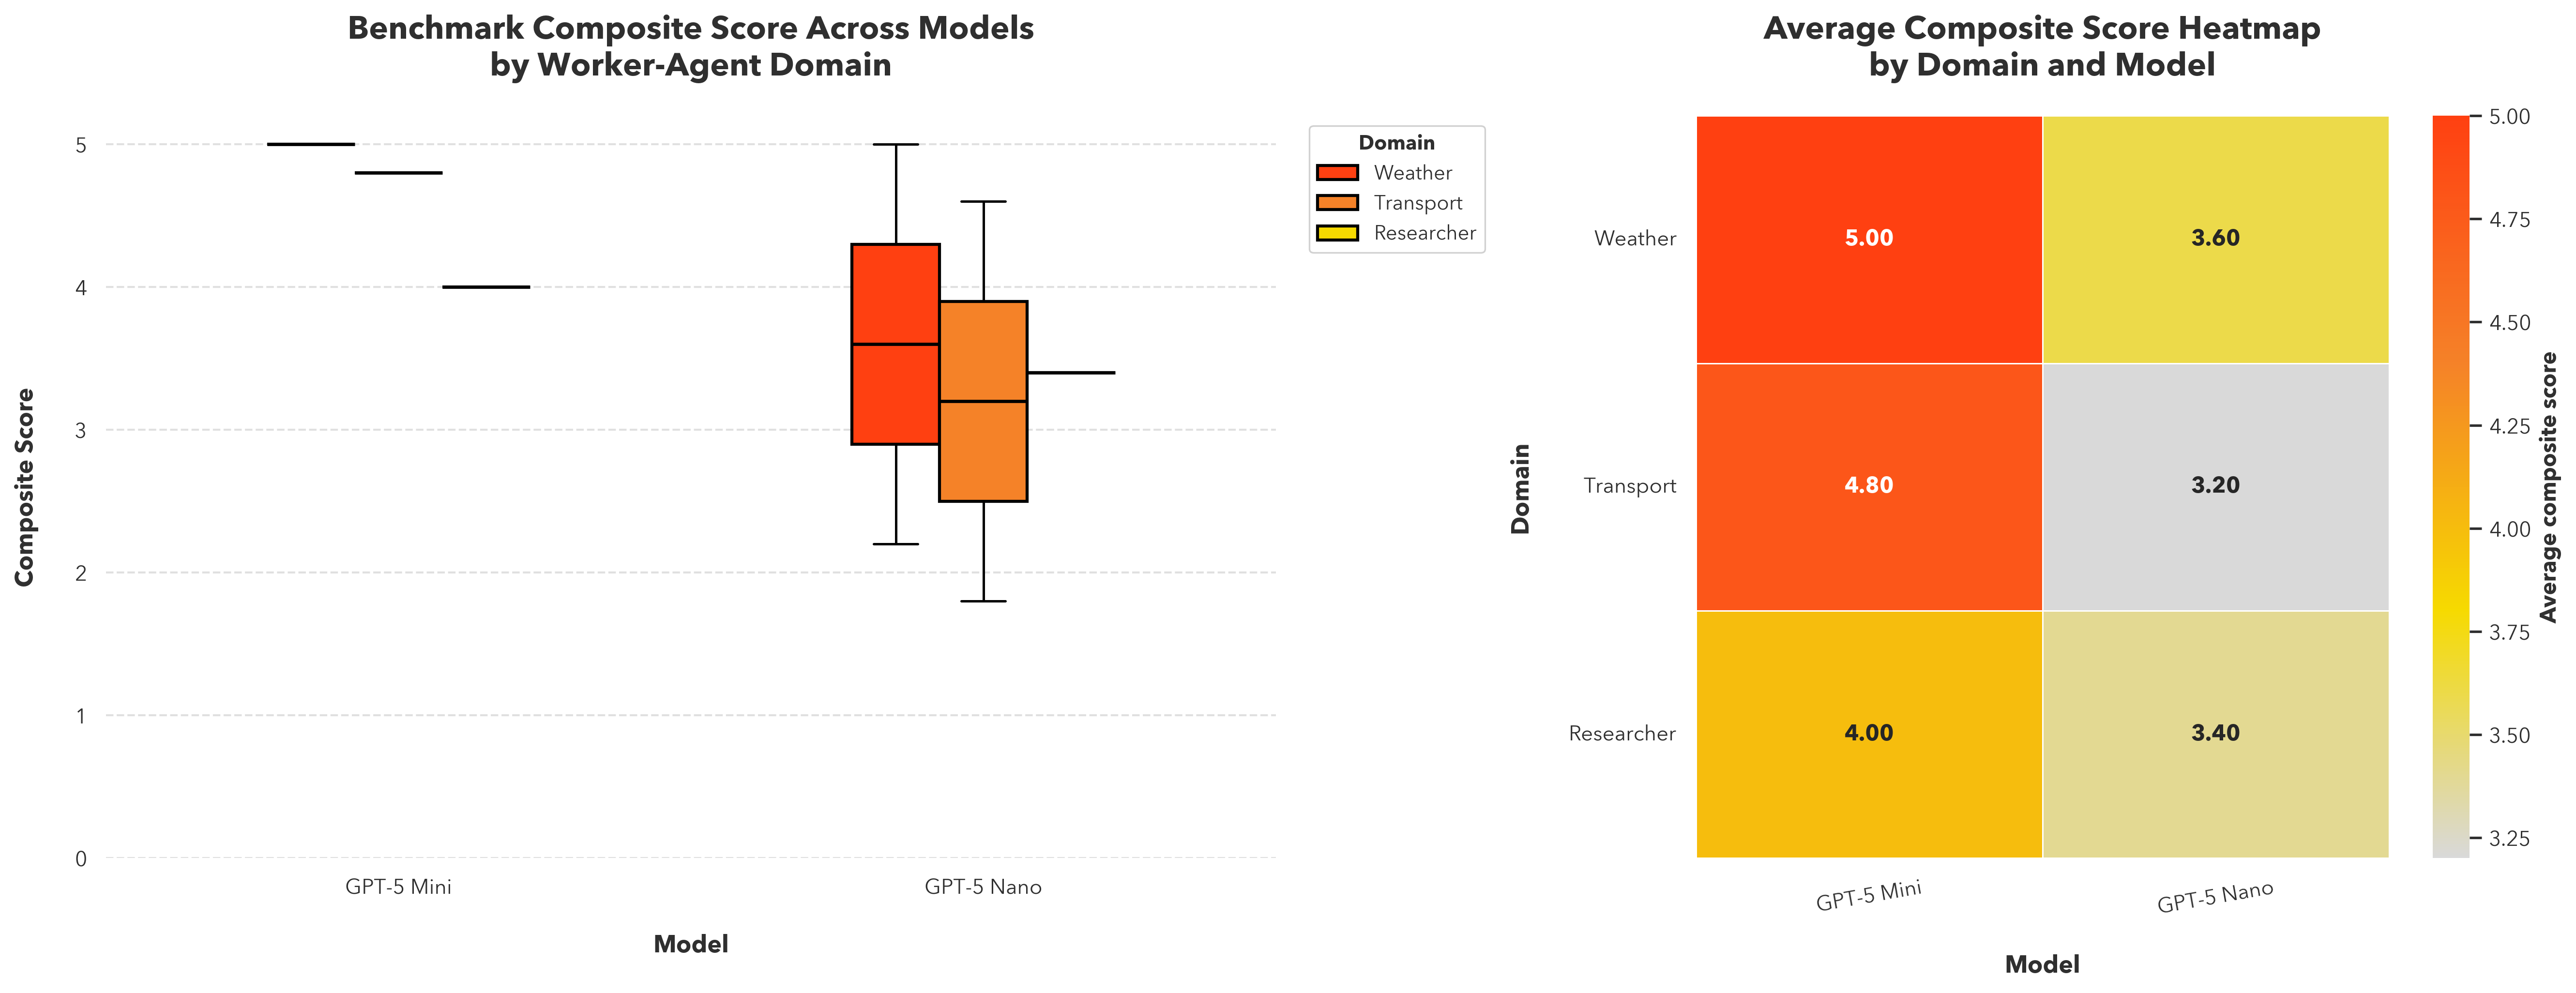

In [27]:
# ==========================================================================
# Benchmark plots
# ==========================================================================
benchmark_heatmap = (
    benchmark_df.pivot_table(
        index='domain_label',
        columns='response_model_label',
        values='composite_score',
        aggfunc='mean',
    )
    .reindex(index=benchmark_domain_order, columns=benchmark_model_order)
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 7),
    dpi=EXPORT_DPI,
    gridspec_kw={'width_ratios': [1.35, 1]},
    facecolor='white',
)

build_metric_boxplot(
    axes[0],
    benchmark_df,
    x='response_model_label',
    y='composite_score',
    hue='domain_label',
    palette=DOMAIN_PALETTE,
    order=benchmark_model_order,
    hue_order=benchmark_domain_order,
    title='Benchmark Composite Score Across Models\nby Worker-Agent Domain',
    xlabel='Model',
    ylabel='Composite Score',
    y_limits=(0, 5.2),
    legend_title='Domain',
    show_legend=True,
)

sns.heatmap(
    benchmark_heatmap,
    annot=True,
    fmt='.2f',
    cmap=sns.blend_palette([LIGHT_GREY, ACCENT_YELLOW, SECONDARY_ORANGE, PRIMARY_RED], as_cmap=True),
    linewidths=0.6,
    linecolor='white',
    cbar_kws={'label': 'Average composite score'},
    annot_kws={'fontsize': 11, 'fontweight': 'bold'},
    ax=axes[1],
)
style_axis(
    axes[1],
    'Average Composite Score Heatmap\nby Domain and Model',
    'Model',
    'Domain',
    rotate_xticks=10,
    show_y_grid=False,
)
axes[1].tick_params(axis='y', rotation=0)
axes[1].collections[0].colorbar.ax.yaxis.label.set_fontweight('bold')
axes[1].collections[0].colorbar.ax.yaxis.label.set_size(11)

plt.tight_layout()
save_figure('benchmark_score_overview', fig)
plt.show()

Exported: benchmark_operational_metrics.svg


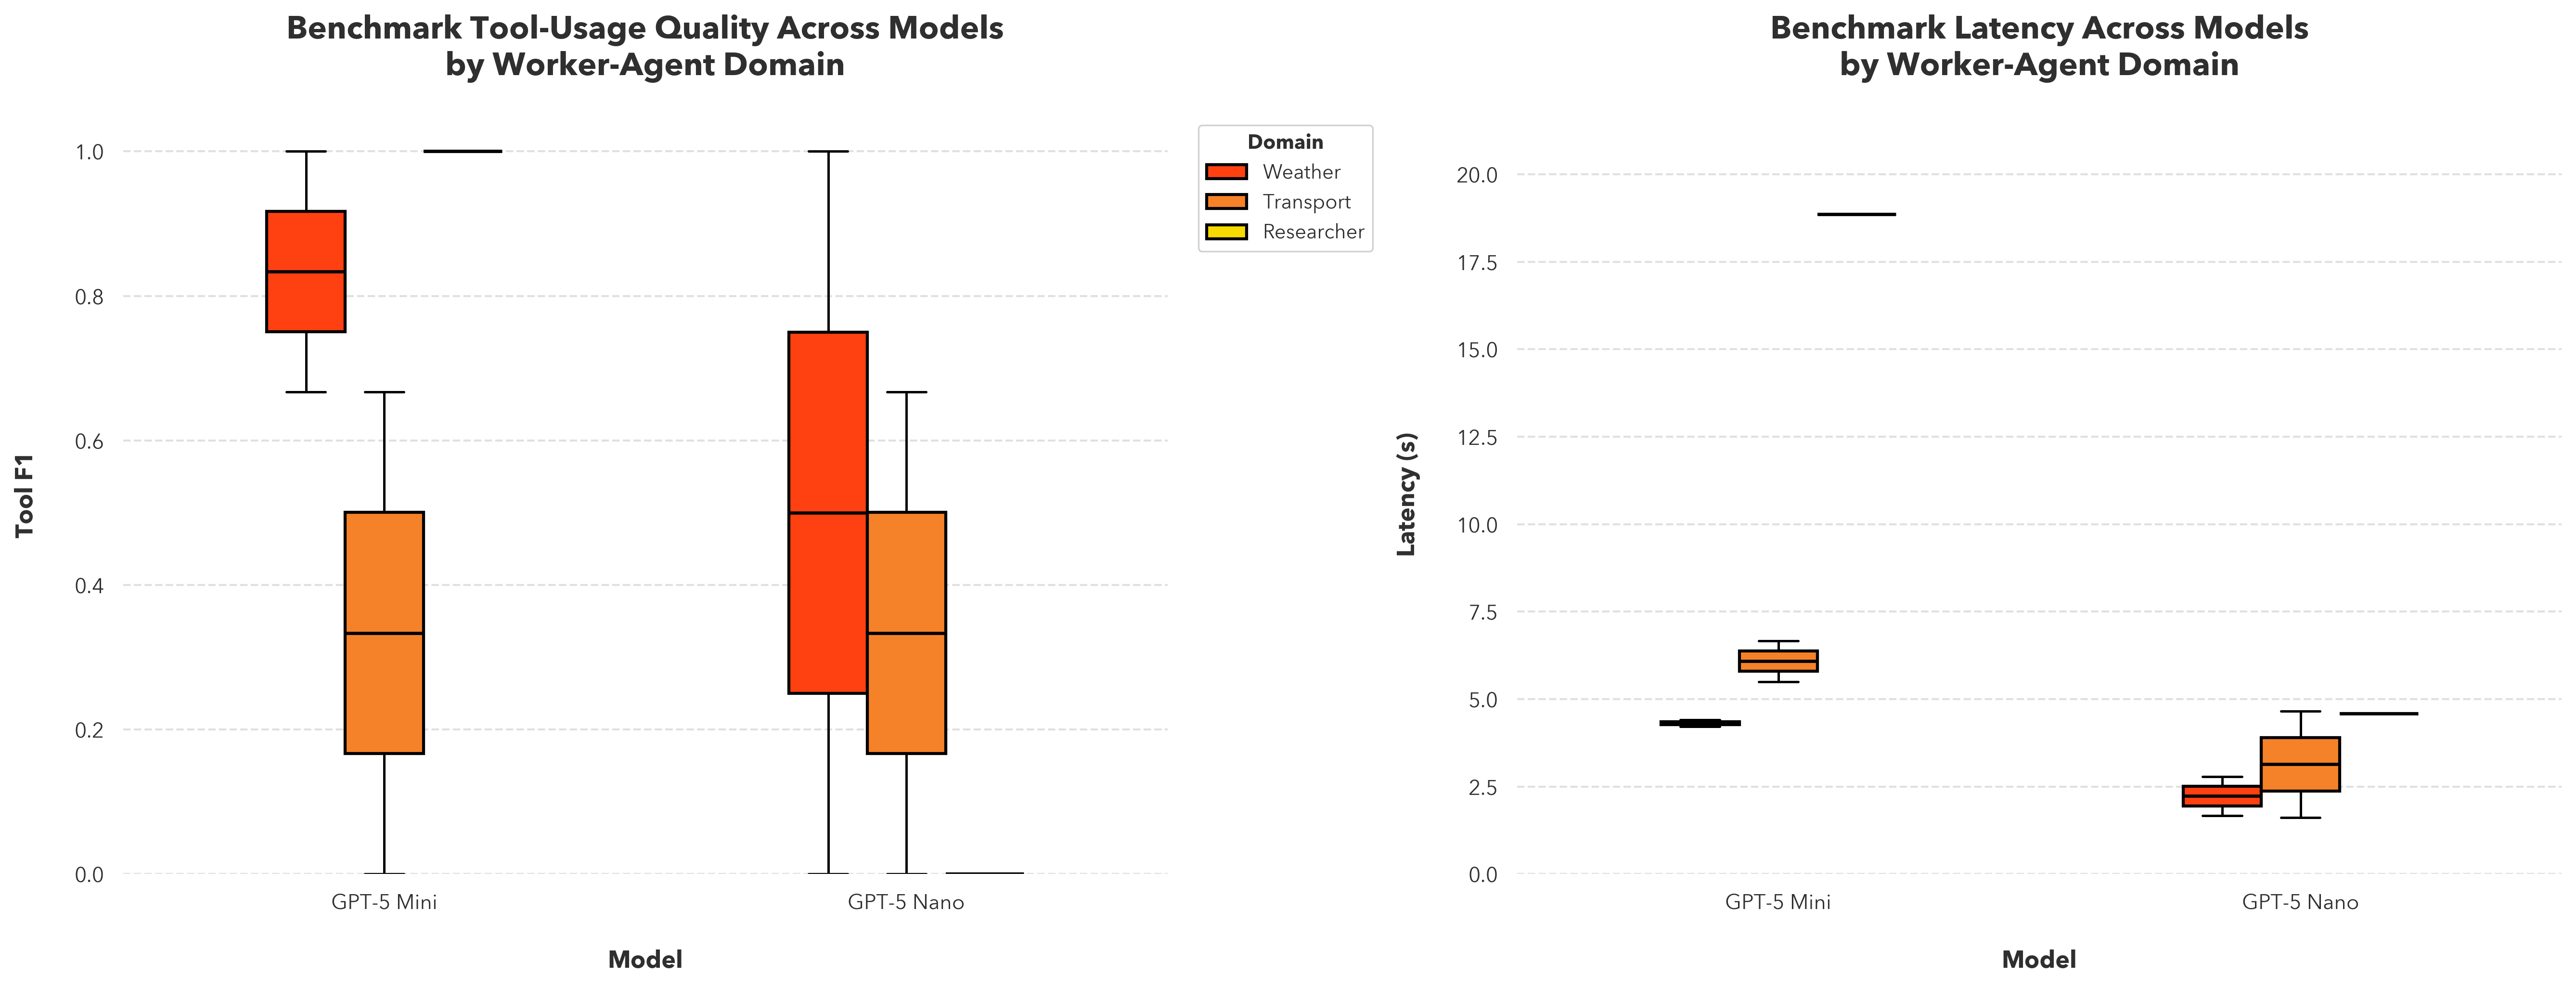

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), dpi=EXPORT_DPI)

latency_upper = max(benchmark_df['latency_s'].max() * 1.15, 5.0)

build_metric_boxplot(
    axes[0],
    benchmark_df,
    x='response_model_label',
    y='tool_f1',
    hue='domain_label',
    palette=DOMAIN_PALETTE,
    order=benchmark_model_order,
    hue_order=benchmark_domain_order,
    title='Benchmark Tool-Usage Quality Across Models\nby Worker-Agent Domain',
    xlabel='Model',
    ylabel='Tool F1',
    y_limits=(0, 1.05),
    legend_title='Domain',
    show_legend=True,
)

build_metric_boxplot(
    axes[1],
    benchmark_df,
    x='response_model_label',
    y='latency_s',
    hue='domain_label',
    palette=DOMAIN_PALETTE,
    order=benchmark_model_order,
    hue_order=benchmark_domain_order,
    title='Benchmark Latency Across Models\nby Worker-Agent Domain',
    xlabel='Model',
    ylabel='Latency (s)',
    y_limits=(0, latency_upper),
    legend_title='Domain',
    show_legend=False,
)

plt.tight_layout()
save_figure('benchmark_operational_metrics', fig)
plt.show()

## **⚖️ Ablation analysis**

The ablation compares the same query set across two arms:

- **zero_shot**: direct model answer without LISBOA tool grounding
- **lisboa**: full multi-agent pipeline with routing, tools, QA, and planning when needed

The goal is to inspect whether the full system improves grounding, tool quality, and robustness over the baseline.

In [6]:
# ==========================================================================
# Ablation tables
# ==========================================================================
ablation_df = flatten_ablation_results(ablation_payload)
ablation_df['arm_label'] = ablation_df['arm'].apply(format_arm_label)
ablation_df['domain_label'] = ablation_df['domain'].apply(format_domain_label)
ablation_df['response_model_label'] = ablation_df['response_model'].apply(format_model_label)
ablation_df['evaluation_model_label'] = ablation_df['evaluation_model'].apply(format_model_label)

ablation_domain_order = [
    label for label in ABLATION_DOMAIN_ORDER if label in ablation_df['domain_label'].unique()
]
ablation_arm_order = ['Zero-shot', 'LISBOA']

ablation_summary = (
    ablation_df.groupby(['arm_label', 'domain_label'], as_index=False)
    .agg(
        avg_composite_score=('composite_score', 'mean'),
        avg_tool_f1=('tool_f1', 'mean'),
        avg_latency_s=('latency_s', 'mean'),
        heuristics_pass_rate=('heuristics_pass', 'mean'),
        avg_response_input_tokens=('response_input_tokens', 'mean'),
        avg_response_output_tokens=('response_output_tokens', 'mean'),
        avg_response_total_tokens=('response_total_tokens', 'mean'),
        avg_evaluation_input_tokens=('evaluation_input_tokens', 'mean'),
        avg_evaluation_output_tokens=('evaluation_output_tokens', 'mean'),
        avg_evaluation_total_tokens=('evaluation_total_tokens', 'mean'),
        avg_combined_input_tokens=('combined_input_tokens', 'mean'),
        avg_combined_output_tokens=('combined_output_tokens', 'mean'),
        avg_combined_total_tokens=('combined_total_tokens', 'mean'),
        avg_response_cost_usd=('response_total_cost_usd', 'mean'),
        avg_evaluation_cost_usd=('evaluation_total_cost_usd', 'mean'),
        avg_combined_cost_usd=('combined_total_cost_usd', 'mean'),
        total_response_cost_usd=('response_total_cost_usd', 'sum'),
        total_evaluation_cost_usd=('evaluation_total_cost_usd', 'sum'),
        total_combined_cost_usd=('combined_total_cost_usd', 'sum'),
    )
)
ablation_summary['arm_label'] = pd.Categorical(
    ablation_summary['arm_label'],
    categories=ablation_arm_order,
    ordered=True,
)
ablation_summary['domain_label'] = pd.Categorical(
    ablation_summary['domain_label'],
    categories=ablation_domain_order,
    ordered=True,
)
ablation_summary = ablation_summary.sort_values(['arm_label', 'domain_label'])

ablation_delta = (
    ablation_df.pivot_table(
        index=['id', 'domain_label', 'query'],
        columns='arm_label',
        values='composite_score',
        aggfunc='first',
    )
    .reset_index()
)
ablation_delta['lisboa_minus_zero_shot'] = ablation_delta['LISBOA'] - ablation_delta['Zero-shot']
ablation_delta = ablation_delta.sort_values(['domain_label', 'id'])

ablation_table = ablation_summary.rename(
    columns={
        'arm_label': 'Arm',
        'domain_label': 'Domain',
        'avg_composite_score': 'Avg composite score',
        'avg_tool_f1': 'Avg tool F1',
        'avg_latency_s': 'Avg latency (s)',
        'heuristics_pass_rate': 'Heuristics pass rate',
        'avg_response_input_tokens': 'Avg response input tokens',
        'avg_response_output_tokens': 'Avg response output tokens',
        'avg_response_total_tokens': 'Avg response total tokens',
        'avg_evaluation_input_tokens': 'Avg eval input tokens',
        'avg_evaluation_output_tokens': 'Avg eval output tokens',
        'avg_evaluation_total_tokens': 'Avg eval total tokens',
        'avg_combined_input_tokens': 'Avg combined input tokens',
        'avg_combined_output_tokens': 'Avg combined output tokens',
        'avg_combined_total_tokens': 'Avg combined total tokens',
        'avg_response_cost_usd': 'Avg response cost (USD)',
        'avg_evaluation_cost_usd': 'Avg eval cost (USD)',
        'avg_combined_cost_usd': 'Avg combined cost (USD)',
        'total_response_cost_usd': 'Total response cost (USD)',
        'total_evaluation_cost_usd': 'Total eval cost (USD)',
        'total_combined_cost_usd': 'Total combined cost (USD)',
    }
)

ablation_delta_table = ablation_df[[
    'id', 'domain_label', 'arm_label', 'combined_total_tokens', 'combined_total_cost_usd'
 ]].rename(
    columns={
        'domain_label': 'Domain',
        'arm_label': 'Arm',
        'combined_total_tokens': 'Combined total tokens',
        'combined_total_cost_usd': 'Combined total cost (USD)',
    }
).sort_values(['Domain', 'id', 'Arm'])

display(Markdown('### Ablation grouped metrics'))
display(ablation_table.round(6))

display(Markdown('### Ablation per-arm token and cost view'))
display(ablation_delta_table.round(6))

### Ablation grouped metrics

,Arm,Domain,Avg composite score,Avg tool F1,Avg latency (s),Heuristics pass rate,Avg response input tokens,Avg response output tokens,Avg response total tokens,Avg eval input tokens,...,Avg eval total tokens,Avg combined input tokens,Avg combined output tokens,Avg combined total tokens,Avg response cost (USD),Avg eval cost (USD),Avg combined cost (USD),Total response cost (USD),Total eval cost (USD),Total combined cost (USD)
5,Zero-shot,Greeting,4.8,1.000,0.546,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,Zero-shot,Weather,2.6,0.000,3.540,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,Zero-shot,Transport,3.0,0.000,1.433,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,Zero-shot,Researcher,3.8,0.000,6.471,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,Zero-shot,Multi-agent,3.2,0.000,14.150,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0,LISBOA,Greeting,5.0,1.000,0.938,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,LISBOA,Weather,5.0,1.000,14.295,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,LISBOA,Transport,4.0,0.000,14.698,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,LISBOA,Researcher,3.6,1.000,17.792,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,LISBOA,Multi-agent,3.2,0.571,34.087,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Ablation per-arm token and cost view

,id,Domain,Arm,Combined total tokens,Combined total cost (USD)
9,G01,Greeting,LISBOA,0,0.0
8,G01,Greeting,Zero-shot,0,0.0
7,M01,Multi-agent,LISBOA,0,0.0
6,M01,Multi-agent,Zero-shot,0,0.0
5,R01,Researcher,LISBOA,0,0.0
4,R01,Researcher,Zero-shot,0,0.0
3,T01,Transport,LISBOA,0,0.0
2,T01,Transport,Zero-shot,0,0.0
1,W01,Weather,LISBOA,0,0.0
0,W01,Weather,Zero-shot,0,0.0


Exported: ablation_domain_comparison.svg


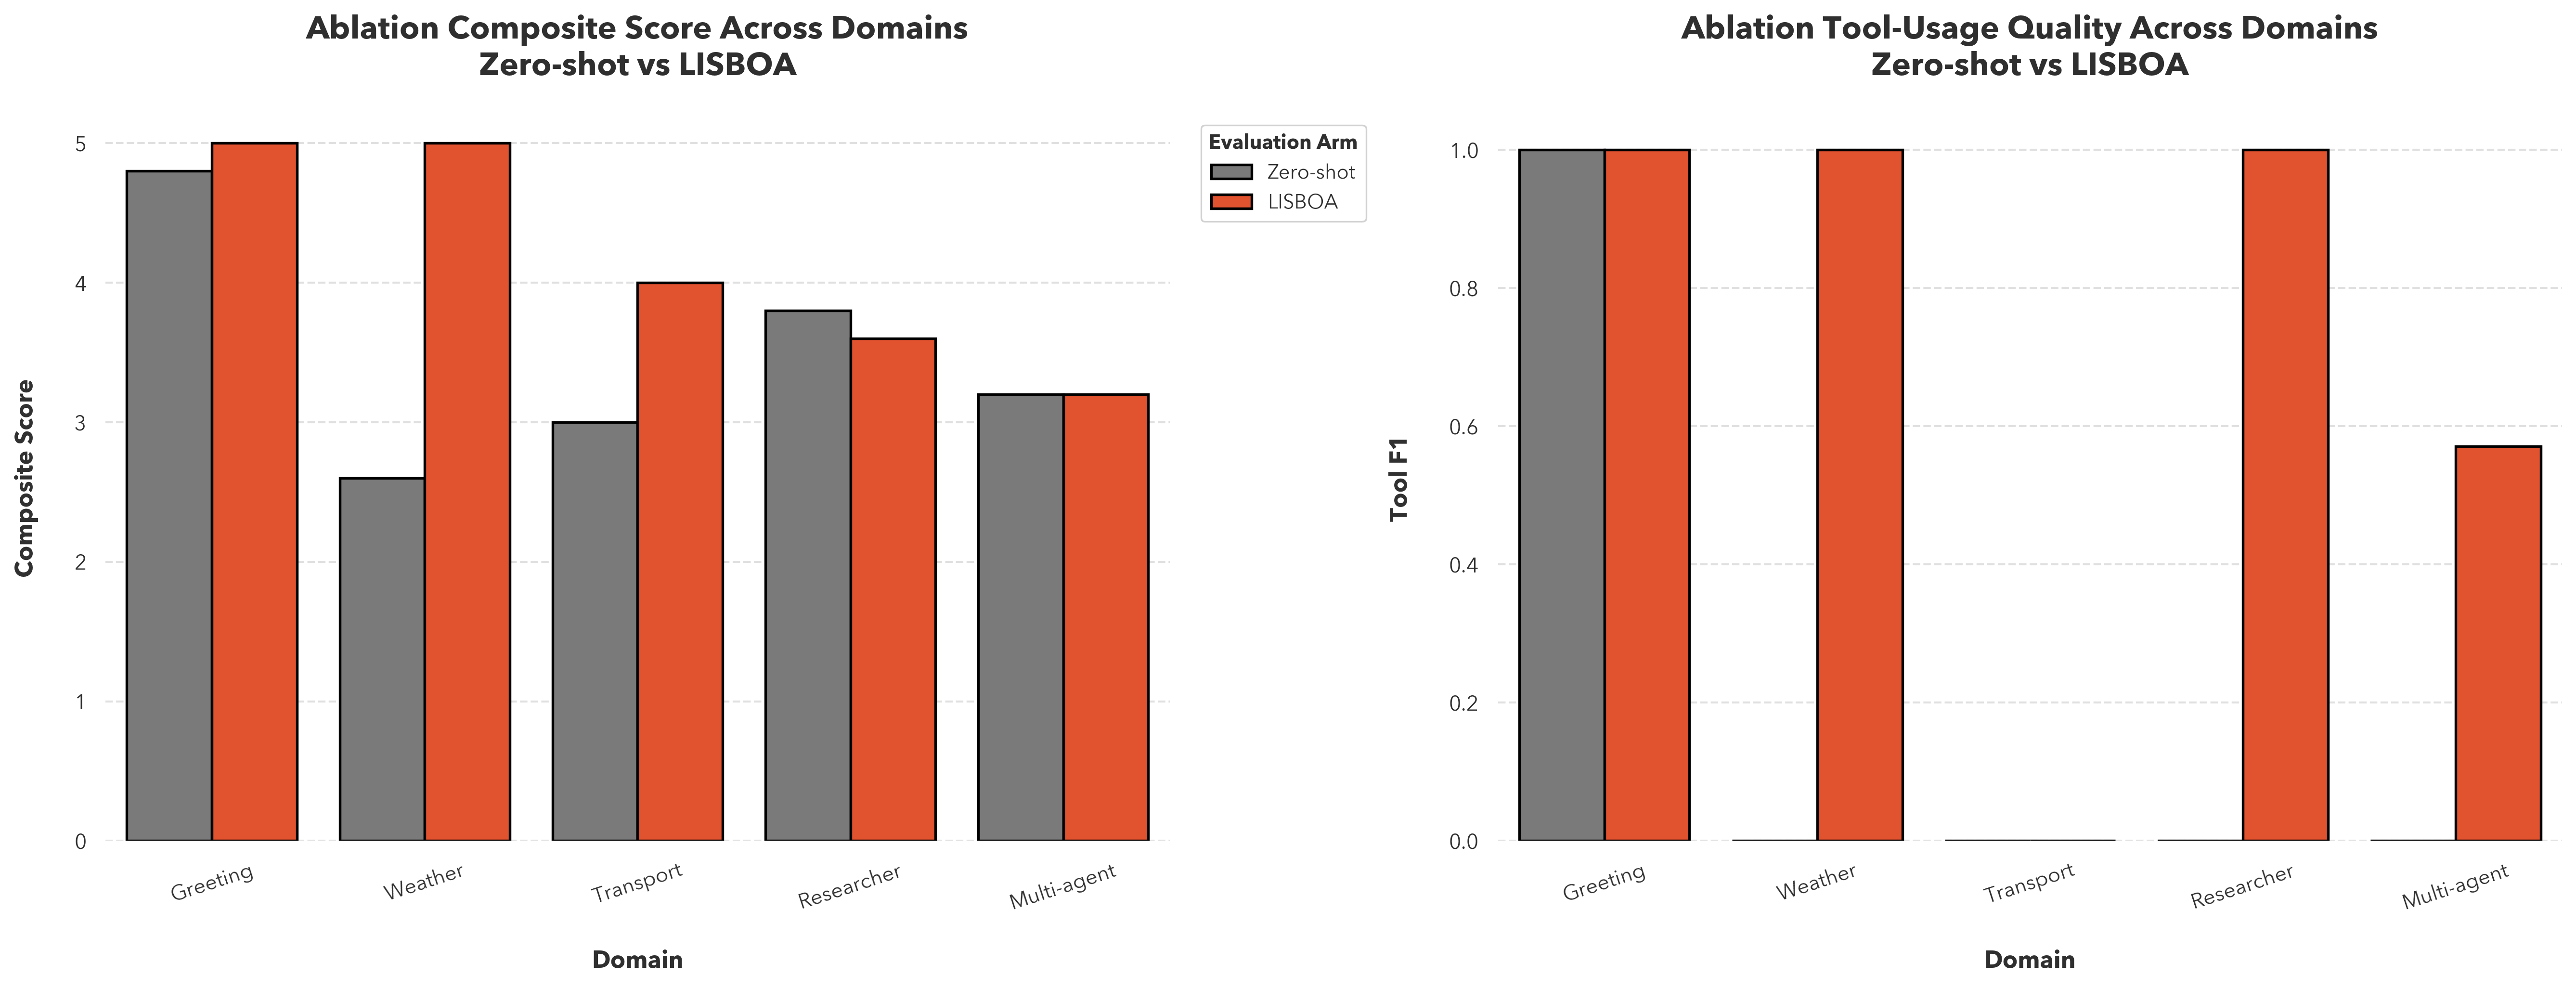

In [29]:
# ==========================================================================
# Ablation plots
# ==========================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7), dpi=EXPORT_DPI, facecolor='white')

sns.barplot(
    data=ablation_summary,
    x='domain_label',
    y='avg_composite_score',
    hue='arm_label',
    order=ablation_domain_order,
    hue_order=ablation_arm_order,
    palette=ARM_PALETTE,
    edgecolor='black',
    linewidth=1.3,
    ax=axes[0],
)
style_axis(
    axes[0],
    'Ablation Composite Score Across Domains\nZero-shot vs LISBOA',
    'Domain',
    'Composite Score',
    rotate_xticks=18,
    y_limits=(0, 5.2),
    show_y_grid=True,
)
style_legend(axes[0], 'Evaluation Arm')

sns.barplot(
    data=ablation_summary,
    x='domain_label',
    y='avg_tool_f1',
    hue='arm_label',
    order=ablation_domain_order,
    hue_order=ablation_arm_order,
    palette=ARM_PALETTE,
    edgecolor='black',
    linewidth=1.3,
    ax=axes[1],
)
style_axis(
    axes[1],
    'Ablation Tool-Usage Quality Across Domains\nZero-shot vs LISBOA',
    'Domain',
    'Tool F1',
    rotate_xticks=18,
    y_limits=(0, 1.05),
    show_y_grid=True,
)
if axes[1].legend_ is not None:
    axes[1].legend_.remove()

plt.tight_layout()
save_figure('ablation_domain_comparison', fig)
plt.show()

Exported: ablation_operational_delta.svg


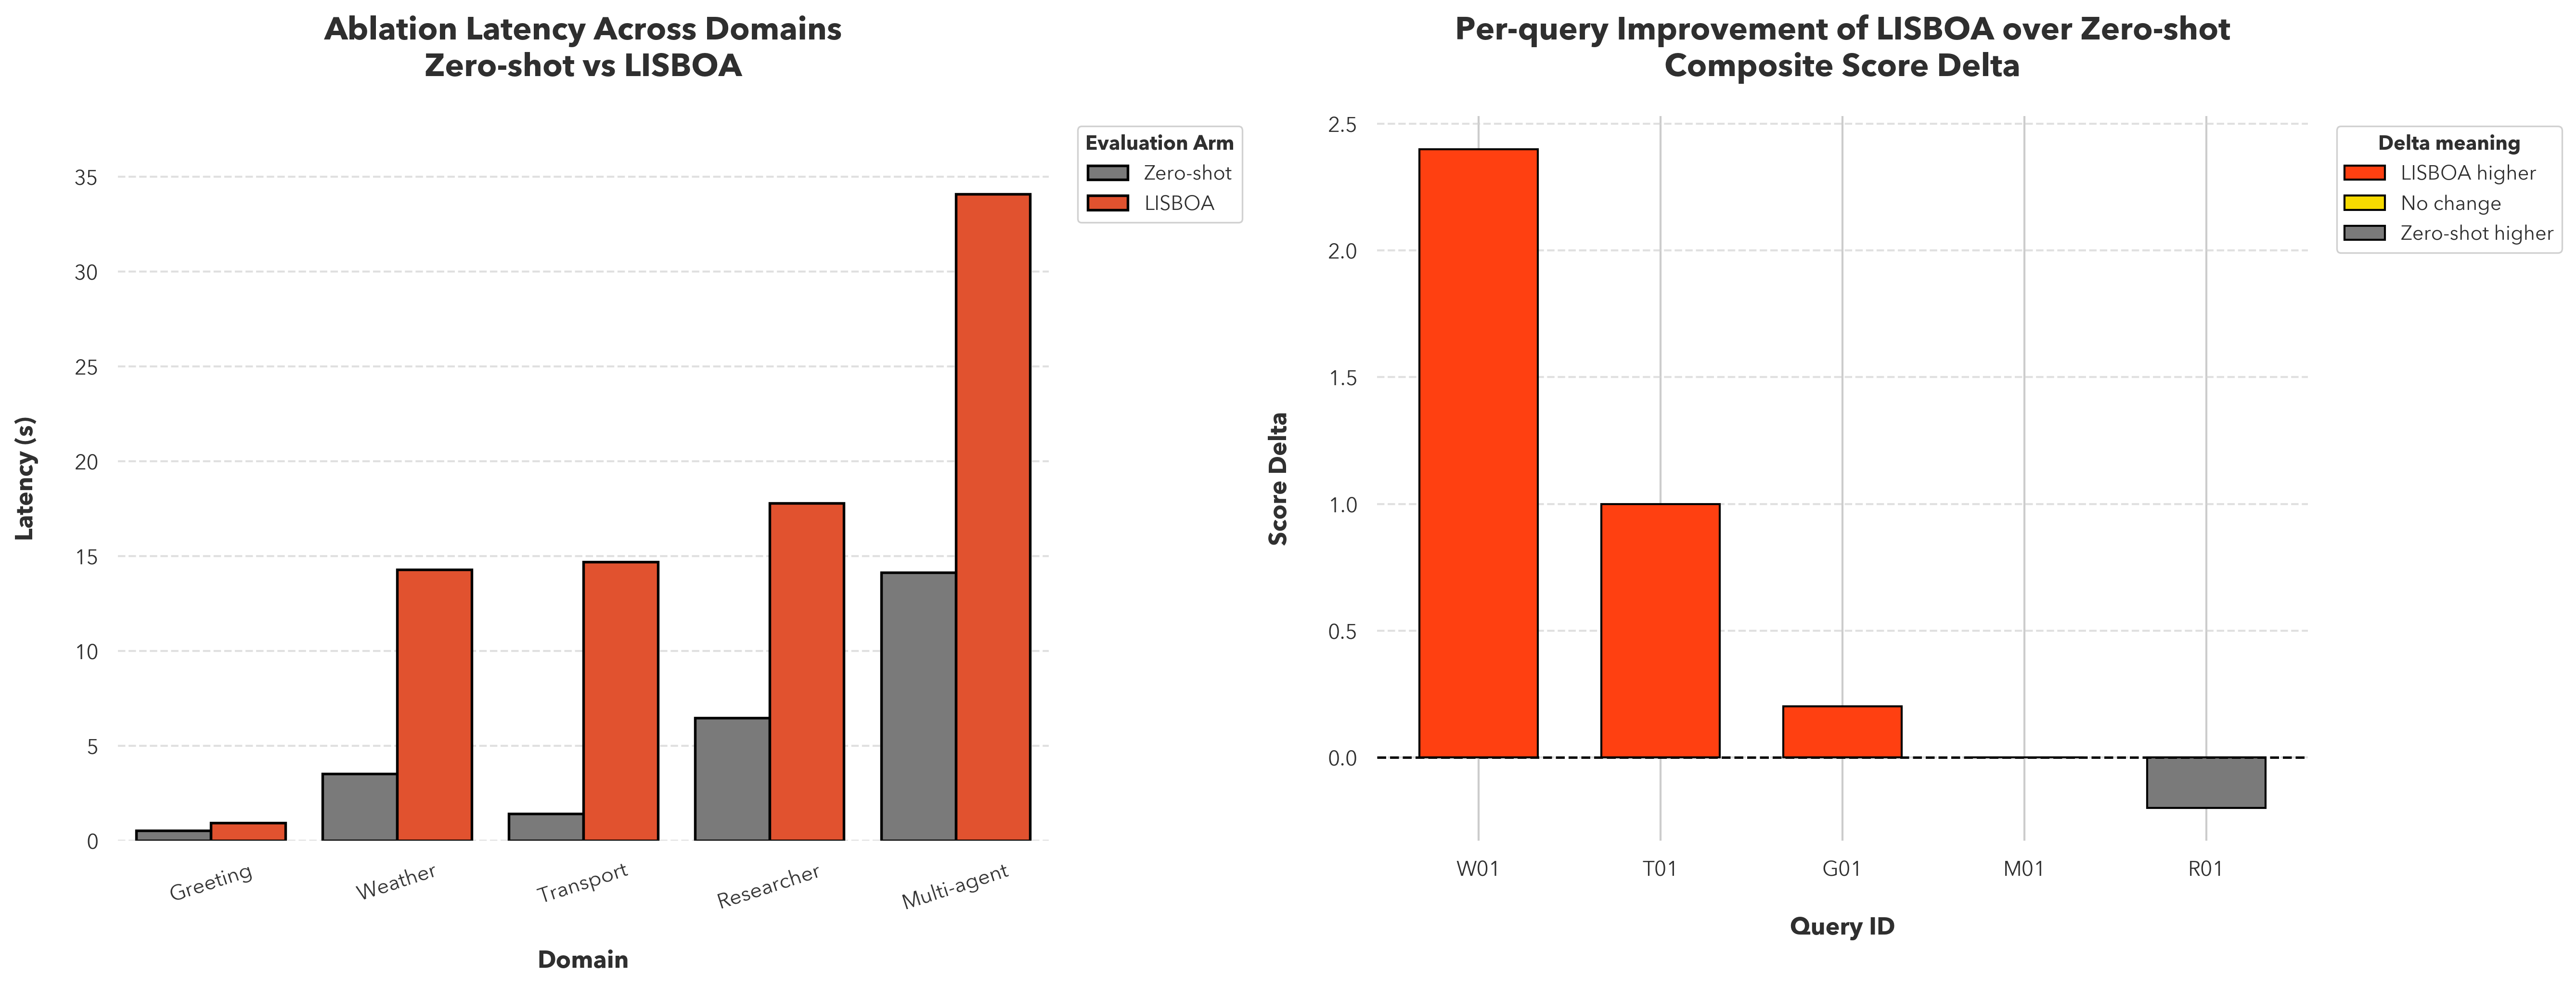

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), dpi=EXPORT_DPI, facecolor='white')

ablation_latency_upper = max(ablation_summary['avg_latency_s'].max() * 1.12, 5.0)

sns.barplot(
    data=ablation_summary,
    x='domain_label',
    y='avg_latency_s',
    hue='arm_label',
    order=ablation_domain_order,
    hue_order=ablation_arm_order,
    palette=ARM_PALETTE,
    edgecolor='black',
    linewidth=1.3,
    ax=axes[0],
)
style_axis(
    axes[0],
    'Ablation Latency Across Domains\nZero-shot vs LISBOA',
    'Domain',
    'Latency (s)',
    rotate_xticks=18,
    y_limits=(0, ablation_latency_upper),
    show_y_grid=True,
)
style_legend(axes[0], 'Evaluation Arm')

delta_plot = ablation_delta.sort_values('lisboa_minus_zero_shot', ascending=False).copy()
delta_plot['delta_label'] = delta_plot['lisboa_minus_zero_shot']
delta_plot['bar_color'] = np.where(
    delta_plot['delta_label'] > 0,
    PRIMARY_RED,
    np.where(delta_plot['delta_label'] < 0, NEUTRAL_GREY, ACCENT_YELLOW)
)

axes[1].bar(
    delta_plot['id'],
    delta_plot['delta_label'],
    color=delta_plot['bar_color'],
    edgecolor='black',
    linewidth=1.0,
    width=0.65,
)
axes[1].axhline(0, color='black', linewidth=1.2, linestyle='--')
style_axis(
    axes[1],
    'Per-query Improvement of LISBOA over Zero-shot\nComposite Score Delta',
    'Query ID',
    'Score Delta',
    show_y_grid=True,
)
legend_handles = [
    Patch(facecolor=PRIMARY_RED, edgecolor='black', label='LISBOA higher'),
    Patch(facecolor=ACCENT_YELLOW, edgecolor='black', label='No change'),
    Patch(facecolor=NEUTRAL_GREY, edgecolor='black', label='Zero-shot higher'),
]
axes[1].legend(handles=legend_handles, title='Delta meaning', loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=True)
axes[1].legend_.get_title().set_fontweight('bold')
axes[1].legend_.get_frame().set_edgecolor('#d0d0d0')
axes[1].legend_.get_frame().set_linewidth(0.8)
axes[1].legend_.get_frame().set_alpha(0.98)

plt.tight_layout()
save_figure('ablation_operational_delta', fig)
plt.show()

In [25]:
# ==========================================================================
# Optional coverage and calibration context
# ==========================================================================
if coverage_payload is not None:
    coverage_df = pd.DataFrame(coverage_payload.get('coverage_results', []))
    if not coverage_df.empty:
        coverage_df['domain_label'] = coverage_df['domain'].apply(format_domain_label)
        coverage_df['response_model_label'] = coverage_df['response_model'].apply(format_model_label)
    display(Markdown('### Optional coverage artefact snapshot'))
    display(coverage_df[['id', 'domain_label', 'response_model_label', 'coverage_pass', 'latency_s']].head(10).rename(
        columns={
            'domain_label': 'Domain',
            'response_model_label': 'Response model',
            'coverage_pass': 'Coverage pass',
            'latency_s': 'Latency (s)',
        }
    ))
else:
    print('No coverage JSON found yet. Run the strict live coverage suite to populate this section.')

if calibration_payload is not None:
    calibration_summary = pd.json_normalize(calibration_payload.get('summary', {}).get('per_dimension', {}), sep='.')
    display(Markdown('### Optional calibration artefact snapshot'))
    display(calibration_summary.T)
else:
    print('No calibration JSON found yet. Run the human calibration script when scores are available.')

No coverage JSON found yet. Run the strict live coverage suite to populate this section.
No calibration JSON found yet. Run the human calibration script when scores are available.


In [26]:
# ==========================================================================
# Export flat tables for downstream writing / appendix work
# ==========================================================================
benchmark_flat_path = EVAL_RESULTS_DIR / 'benchmark' / 'benchmark_flat_latest.csv'
benchmark_summary_path = EVAL_RESULTS_DIR / 'benchmark' / 'benchmark_summary_latest.csv'
ablation_flat_path = EVAL_RESULTS_DIR / 'ablation' / 'ablation_flat_latest.csv'
ablation_summary_path = EVAL_RESULTS_DIR / 'ablation' / 'ablation_summary_latest.csv'

benchmark_df.to_csv(benchmark_flat_path, index=False)
benchmark_summary.to_csv(benchmark_summary_path, index=False)
ablation_df.to_csv(ablation_flat_path, index=False)
ablation_summary.to_csv(ablation_summary_path, index=False)

print('Exported flat tables:')
print(f' - {benchmark_flat_path.relative_to(PROJECT_ROOT)}')
print(f' - {benchmark_summary_path.relative_to(PROJECT_ROOT)}')
print(f' - {ablation_flat_path.relative_to(PROJECT_ROOT)}')
print(f' - {ablation_summary_path.relative_to(PROJECT_ROOT)}')

Exported flat tables:
 - eval\results\benchmark\benchmark_flat_latest.csv
 - eval\results\benchmark\benchmark_summary_latest.csv
 - eval\results\ablation\ablation_flat_latest.csv
 - eval\results\ablation\ablation_summary_latest.csv


## **📌 Notes for thesis writing**

- The notebook always uses the latest timestamped JSON artefacts in each results folder.
- Figures are exported automatically as **SVG only**, which is the cleanest option for thesis writing, resizing, and vector-safe reuse in Word, PowerPoint, or LaTeX.
- Legacy **PNG** and **PDF** versions are removed automatically when a figure is re-exported, so the figures folder stays tidy.
- Model names shown in tables and plots are cleaned for presentation, for example `GPT-5 Mini`, `GPT-5 Nano`, and `LISBOA Multi-Agent`.
- Flat CSV tables are also exported to simplify appendix creation, manual inspection, or import into external reporting tools.
- If you later benchmark additional models, the same notebook should continue to work because it reads the persisted response-model and evaluator-model metadata directly from the JSON files.